In [1]:
import os
for root, dirs, files in os.walk('/kaggle/input'):
    if dirs:
        print(f"Path: {root}")
        print(f"Contains Folders: {dirs[:5]}") # Show first 5 folders
        print("-" * 30)

Path: /kaggle/input
Contains Folders: ['datasets']
------------------------------
Path: /kaggle/input/datasets
Contains Folders: ['ritam192']
------------------------------
Path: /kaggle/input/datasets/ritam192
Contains Folders: ['ucf-crime-features-step5-train', 'ucf-crime-features-step5-test']
------------------------------


In [2]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DIR = "/kaggle/input/datasets/ritam192/ucf-crime-features-step5-train"

CRIME_CLASSES = [
    'Abuse', 'Arrest', 'Assault', 'Burglary', 
    'Fighting', 'RoadAccidents', 'Robbery', 'Shooting', 
    'Shoplifting', 'Stealing', 'Vandalism'
]

class_to_idx = {cls: i for i, cls in enumerate(CRIME_CLASSES)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}
NUM_CLASSES = len(CRIME_CLASSES)

print(f"Layer 2 Initialized for {NUM_CLASSES} crime categories.")

Layer 2 Initialized for 11 crime categories.


In [3]:
def load_categorical_data_from_files(base_dir):
    X_list, y_list = [], []
    
    # We map the exact filenames from your screenshot
    # Note: Arson and Explosion are omitted as per your request
    crime_files = {
        'Abuse': 'Abuse_feat.npy',
        'Arrest': 'Arrest_feat.npy',
        'Assault': 'Assault_feat.npy',
        'Burglary': 'Burglary_feat.npy',
        'Fighting': 'Fighting_feat.npy',
        'RoadAccidents': 'RoadAccidents_feat.npy',
        'Robbery': 'Robbery_feat.npy',
        'Shooting': 'Shooting_feat.npy',
        'Shoplifting': 'Shoplifting_feat.npy',
        'Stealing': 'Stealing_feat.npy',
        'Vandalism': 'Vandalism_feat.npy'
    }

    print(f"Loading files from: {base_dir}")

    for crime_name, file_name in crime_files.items():
        file_path = os.path.join(base_dir, file_name)
        
        if os.path.exists(file_path):
            try:
                # Load the stacked sequences
                data = np.load(file_path) # Shape should be (N, 30, 3)
                print(f"✅ Found {data.shape[0]} sequences for {crime_name}")
                
                # Feature Engineering (Velocity + Accel)
                # We apply this to the 2nd axis (the 30 frames)
                deltas = np.diff(data, axis=1, prepend=data[:, :1, :])
                accels = np.diff(deltas, axis=1, prepend=deltas[:, :1, :])
                combined = np.concatenate([data, deltas, accels], axis=2) # Result: (N, 30, 9)
                
                X_list.append(combined)
                # Create a label array for all sequences in this file
                y_list.append(np.full(data.shape[0], class_to_idx[crime_name]))
                
            except Exception as e:
                print(f"❌ Error loading {file_name}: {e}")
        else:
            print(f"⚠️ File missing: {file_name}")

    if not X_list:
        raise ValueError("No data found! Check if TRAIN_DIR is exactly '/kaggle/input/datasets/ritam192/ucf-crime-features-step5-train'")

    # Concatenate all crime blocks into one big dataset
    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    print(f"\nFinal Combined Shape: {X.shape}") # Goal: (Total_Samples, 30, 9)

    # Scaling
    mean = X.mean(axis=(0, 1), keepdims=True)
    std = X.std(axis=(0, 1), keepdims=True)
    X_final = (X - mean) / (std + 1e-6)
    
    return train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# Execute
X_train, X_val, y_train, y_val = load_categorical_data_from_files(TRAIN_DIR)

Loading files from: /kaggle/input/datasets/ritam192/ucf-crime-features-step5-train
✅ Found 3810 sequences for Abuse
✅ Found 5274 sequences for Arrest
✅ Found 2066 sequences for Assault
✅ Found 7895 sequences for Burglary
✅ Found 4931 sequences for Fighting
✅ Found 4692 sequences for RoadAccidents
✅ Found 8293 sequences for Robbery
✅ Found 1422 sequences for Shooting
✅ Found 4961 sequences for Shoplifting
✅ Found 8955 sequences for Stealing
✅ Found 2720 sequences for Vandalism

Final Combined Shape: (55019, 30, 9)


In [4]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, 1)
    def forward(self, x):
        weights = F.softmax(torch.tanh(self.attn(x)), dim=1)
        return torch.sum(weights * x, dim=1)

class SpecialistV1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(9, 128, num_layers=3, batch_first=True, bidirectional=True, dropout=0.4)
        self.attention = Attention(128)
        self.max_pool = nn.AdaptiveMaxPool1d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(256 + 256, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes) # NUM_CLASSES is 11
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out = self.attention(lstm_out)
        pool_out = self.max_pool(lstm_out.transpose(1, 2)).squeeze(-1)
        combined = torch.cat([attn_out, pool_out], dim=1)
        return self.fc(combined)

In [5]:
# Model 1
# 1. Prepare DataLoaders
train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val)), batch_size=32, shuffle=False)

# 2. Initialize Model
model = SpecialistV1(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss() 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

# 3. Training Logic
epochs = 100
print(f"--- Training Specialist (Layer 2: {NUM_CLASSES} Classes) ---")

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation Phase
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            outputs = model(xb)
            val_loss += criterion(outputs, yb).item()
            _, predicted = torch.max(outputs, 1) # Pick the index with highest score
            total += yb.size(0)
            correct += (predicted == yb).sum().item()
    
    avg_train = train_loss/len(train_loader)
    avg_val = val_loss/len(val_loader)
    acc = 100 * correct / total
    
    scheduler.step(avg_val)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d} | Loss: {avg_train:.4f} | Val Acc: {acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

# 4. Save the Specialist Brain
torch.save(model.state_dict(), "specialist_l2_v1.pth")
print("\n✅ Layer 2 Training Complete and Saved!")

--- Training Specialist (Layer 2: 11 Classes) ---
Epoch 01 | Loss: 2.0720 | Val Acc: 30.33% | LR: 0.001000
Epoch 05 | Loss: 1.8773 | Val Acc: 36.29% | LR: 0.001000
Epoch 10 | Loss: 1.5498 | Val Acc: 46.95% | LR: 0.001000
Epoch 15 | Loss: 1.3085 | Val Acc: 53.42% | LR: 0.001000
Epoch 20 | Loss: 1.1784 | Val Acc: 58.02% | LR: 0.001000
Epoch 25 | Loss: 1.0990 | Val Acc: 60.01% | LR: 0.001000
Epoch 30 | Loss: 1.0385 | Val Acc: 61.01% | LR: 0.001000
Epoch 35 | Loss: 0.9931 | Val Acc: 61.88% | LR: 0.001000
Epoch 40 | Loss: 0.9620 | Val Acc: 63.19% | LR: 0.001000
Epoch 45 | Loss: 0.9343 | Val Acc: 64.07% | LR: 0.001000
Epoch 50 | Loss: 0.9163 | Val Acc: 64.18% | LR: 0.000500
Epoch 55 | Loss: 0.8337 | Val Acc: 65.53% | LR: 0.000500
Epoch 60 | Loss: 0.7939 | Val Acc: 66.95% | LR: 0.000250
Epoch 65 | Loss: 0.7823 | Val Acc: 67.25% | LR: 0.000250
Epoch 70 | Loss: 0.7648 | Val Acc: 67.50% | LR: 0.000125
Epoch 75 | Loss: 0.7541 | Val Acc: 67.77% | LR: 0.000125
Epoch 80 | Loss: 0.7462 | Val Acc: 67.

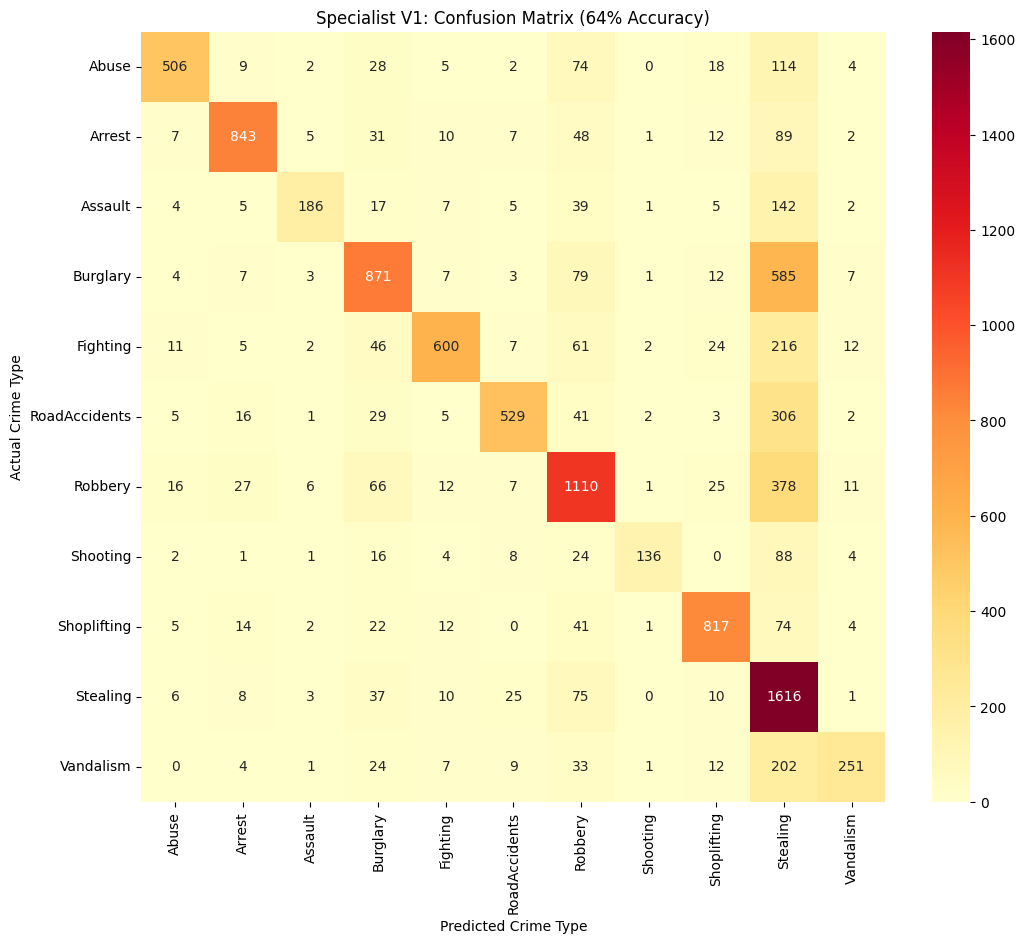

               precision    recall  f1-score   support

        Abuse       0.89      0.66      0.76       762
       Arrest       0.90      0.80      0.85      1055
      Assault       0.88      0.45      0.60       413
     Burglary       0.73      0.55      0.63      1579
     Fighting       0.88      0.61      0.72       986
RoadAccidents       0.88      0.56      0.69       939
      Robbery       0.68      0.67      0.68      1659
     Shooting       0.93      0.48      0.63       284
  Shoplifting       0.87      0.82      0.85       992
     Stealing       0.42      0.90      0.58      1791
    Vandalism       0.84      0.46      0.59       544

     accuracy                           0.68     11004
    macro avg       0.81      0.63      0.69     11004
 weighted avg       0.76      0.68      0.69     11004



In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_specialist(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb.to(DEVICE))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())
            
    # Create the heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=CRIME_CLASSES,
                yticklabels=CRIME_CLASSES)
    plt.xlabel('Predicted Crime Type')
    plt.ylabel('Actual Crime Type')
    plt.title('Specialist V1: Confusion Matrix (64% Accuracy)')
    plt.show()

    # Detailed report per category
    print(classification_report(all_labels, all_preds, target_names=CRIME_CLASSES))

evaluate_specialist(model, val_loader)

In [7]:
# # Model 1 Tuning
# # --- 🛠️ REFINED SPECIALIST (The Stable 85% Path) ---
# model = SpecialistV1(num_classes=NUM_CLASSES).to(DEVICE)

# # 1. Back to a stable Learning Rate
# optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)

# # 2. Use a "Patience" based scheduler instead of the "Cycle"
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)

# # 3. Simplify the Loss (Remove label smoothing for now to regain stability)
# criterion = nn.CrossEntropyLoss(weight=class_weights) 

# best_acc = 0
# print("--- 🛡️ Training Stable Specialist (Target: 85%) ---")

# for epoch in range(80): # More epochs, but moving slower
#     model.train()
#     total_loss = 0
#     for xb, yb in train_loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#         optimizer.zero_grad()
#         loss = criterion(model(xb), yb)
#         loss.backward()
#         # Keep clipping to prevent crashes
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
#         optimizer.step()
#         total_loss += loss.item()
    
#     # Validation
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             outputs = model(xb)
#             _, predicted = torch.max(outputs, 1)
#             total += yb.size(0)
#             correct += (predicted == yb).sum().item()
    
#     current_acc = 100 * correct / total
#     scheduler.step(current_acc) # Tell scheduler to watch accuracy
    
#     if current_acc > best_acc:
#         best_acc = current_acc
#         torch.save(model.state_dict(), "specialist_l2_stable.pth")
    
#     if (epoch + 1) % 5 == 0 or epoch == 0:
#         print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Acc: {current_acc:.2f}% | Best: {best_acc:.2f}%")

# print(f"\n✅ Done! Best stable accuracy: {best_acc:.2f}%")

In [17]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights based on your training labels
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
print("Class weights calculated to balance the model.")

Class weights calculated to balance the model.


In [9]:
# # Model 2
# class SpecialistV2(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         # Wider LSTM to capture complex movement "grammar"
#         self.lstm = nn.LSTM(9, 256, num_layers=3, batch_first=True, bidirectional=True, dropout=0.5)
#         self.attention = Attention(256)
        
#         self.fc = nn.Sequential(
#             nn.Linear(512, 256),
#             nn.LayerNorm(256), 
#             nn.GELU(),         # Smoother than ReLU, helps 80%+ convergence
#             nn.Dropout(0.4),
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Linear(128, num_classes)
#         )

#     def forward(self, x):
#         lstm_out, _ = self.lstm(x)
#         attn_out = self.attention(lstm_out)
#         return self.fc(attn_out)

# # Focal Loss: This ignores easy samples and forces the model to learn hard ones
# class FocalLoss(nn.Module):
#     def __init__(self, weight=None, gamma=2.0):
#         super().__init__()
#         self.gamma = gamma
#         self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none')

#     def forward(self, inputs, targets):
#         ce_loss = self.ce(inputs, targets)
#         pt = torch.exp(-ce_loss)
#         return ((1 - pt) ** self.gamma * ce_loss).mean()

In [10]:
# # 1. Faster DataLoaders
# train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), batch_size=128, shuffle=True)
# val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val)), batch_size=128, shuffle=False)

# # 2. Setup
# model = SpecialistV2(NUM_CLASSES).to(DEVICE)
# optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
# criterion = FocalLoss(weight=class_weights, gamma=2.0) 

# # OneCycleLR is the fastest way to reach peak accuracy
# scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, 
#                                           steps_per_epoch=len(train_loader), 
#                                           epochs=40)

# # 3. Training
# best_acc = 0
# print(f"--- 🚀 EMERGENCY PUSH TO 80%+ (Targeting {NUM_CLASSES} Classes) ---")

# for epoch in range(40): # 40 high-speed epochs
#     model.train()
#     for xb, yb in train_loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#         optimizer.zero_grad()
#         loss = criterion(model(xb), yb)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         scheduler.step()
    
#     # Fast Validation
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             _, predicted = torch.max(model(xb), 1)
#             total += yb.size(0)
#             correct += (predicted == yb).sum().item()
    
#     acc = 100 * correct / total
#     if acc > best_acc:
#         best_acc = acc
#         torch.save(model.state_dict(), "specialist_l2_80plus.pth")
    
#     if (epoch + 1) % 5 == 0 or epoch == 0:
#         print(f"Epoch {epoch+1:02d} | Val Acc: {acc:.2f}% | Best: {best_acc:.2f}%")

# print(f"\n✅ Finished! Peak Accuracy: {best_acc:.2f}%")

In [18]:
# Model 3
class SpecialistV3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Wider, more robust LSTM
        self.lstm = nn.LSTM(9, 256, num_layers=2, batch_first=True, bidirectional=True)
        
        # Multi-Scale Temporal Aggregation
        # This catches different 'speeds' of crime
        self.fast_path = nn.AdaptiveAvgPool1d(1)  # Global average
        self.slow_path = nn.AdaptiveMaxPool1d(1)  # Peak intensity
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x) # (B, 30, 512)
        lstm_out = lstm_out.transpose(1, 2) # (B, 512, 30)
        
        avg_p = self.fast_path(lstm_out).squeeze(-1)
        max_p = self.slow_path(lstm_out).squeeze(-1)
        
        combined = torch.cat([avg_p, max_p], dim=1) # (B, 1024)
        return self.classifier(combined)

In [19]:
def add_noise(batch_x, sigma=0.05):
    noise = torch.randn_like(batch_x) * sigma
    return batch_x + noise

# Updated Training Loop Snippet
for xb, yb in train_loader:
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    
    # Augment: Add slight jitter to the person/vehicle counts
    xb = add_noise(xb) 
    
    optimizer.zero_grad()
    # ... rest of training logic ...

In [20]:
def add_noise(batch_x, sigma=0.05):
    # Only add noise during training to help the model generalize
    noise = torch.randn_like(batch_x) * sigma
    return batch_x + noise

model = SpecialistV3(NUM_CLASSES).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss(weight=class_weights) 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_acc = 0
print("--- 🚨 FINAL PUSH: MULTI-SCALE + NOISE AUGMENTATION ---")

for epoch in range(100):
    # --- TRAINING PHASE ---
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        
        # The Secret Sauce: Jitter the coordinates so the model 
        # doesn't overfit to specific numbers
        xb = add_noise(xb) 
        
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            # NO NOISE during validation
            outputs = model(xb)
            
            val_loss += criterion(outputs, yb).item()
            _, predicted = torch.max(outputs, 1)
            total += yb.size(0)
            correct += (predicted == yb).sum().item()
    
    acc = 100 * correct / total
    scheduler.step()
    
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "specialist_l2_v3_final.pth")
    
    # Print every epoch because of the deadline
    print(f"Epoch {epoch+1:02d} | Loss: {train_loss/len(train_loader):.4f} | Val Acc: {acc:.2f}% | Best: {best_acc:.2f}%")

print(f"\n✅ Final Result: {best_acc:.2f}%")

--- 🚨 FINAL PUSH: MULTI-SCALE + NOISE AUGMENTATION ---
Epoch 01 | Loss: 2.2049 | Val Acc: 26.99% | Best: 26.99%
Epoch 02 | Loss: 2.1134 | Val Acc: 30.29% | Best: 30.29%
Epoch 03 | Loss: 2.0421 | Val Acc: 31.70% | Best: 31.70%
Epoch 04 | Loss: 1.9240 | Val Acc: 35.05% | Best: 35.05%
Epoch 05 | Loss: 1.7573 | Val Acc: 38.87% | Best: 38.87%
Epoch 06 | Loss: 1.5584 | Val Acc: 45.33% | Best: 45.33%
Epoch 07 | Loss: 1.3917 | Val Acc: 50.50% | Best: 50.50%
Epoch 08 | Loss: 1.2621 | Val Acc: 52.20% | Best: 52.20%
Epoch 09 | Loss: 1.1675 | Val Acc: 55.01% | Best: 55.01%
Epoch 10 | Loss: 1.0904 | Val Acc: 57.02% | Best: 57.02%
Epoch 11 | Loss: 1.0471 | Val Acc: 60.40% | Best: 60.40%
Epoch 12 | Loss: 0.9987 | Val Acc: 60.67% | Best: 60.67%
Epoch 13 | Loss: 0.9684 | Val Acc: 62.73% | Best: 62.73%
Epoch 14 | Loss: 0.9431 | Val Acc: 62.40% | Best: 62.73%
Epoch 15 | Loss: 0.9163 | Val Acc: 63.05% | Best: 63.05%
Epoch 16 | Loss: 0.8986 | Val Acc: 63.54% | Best: 63.54%
Epoch 17 | Loss: 0.8772 | Val Acc

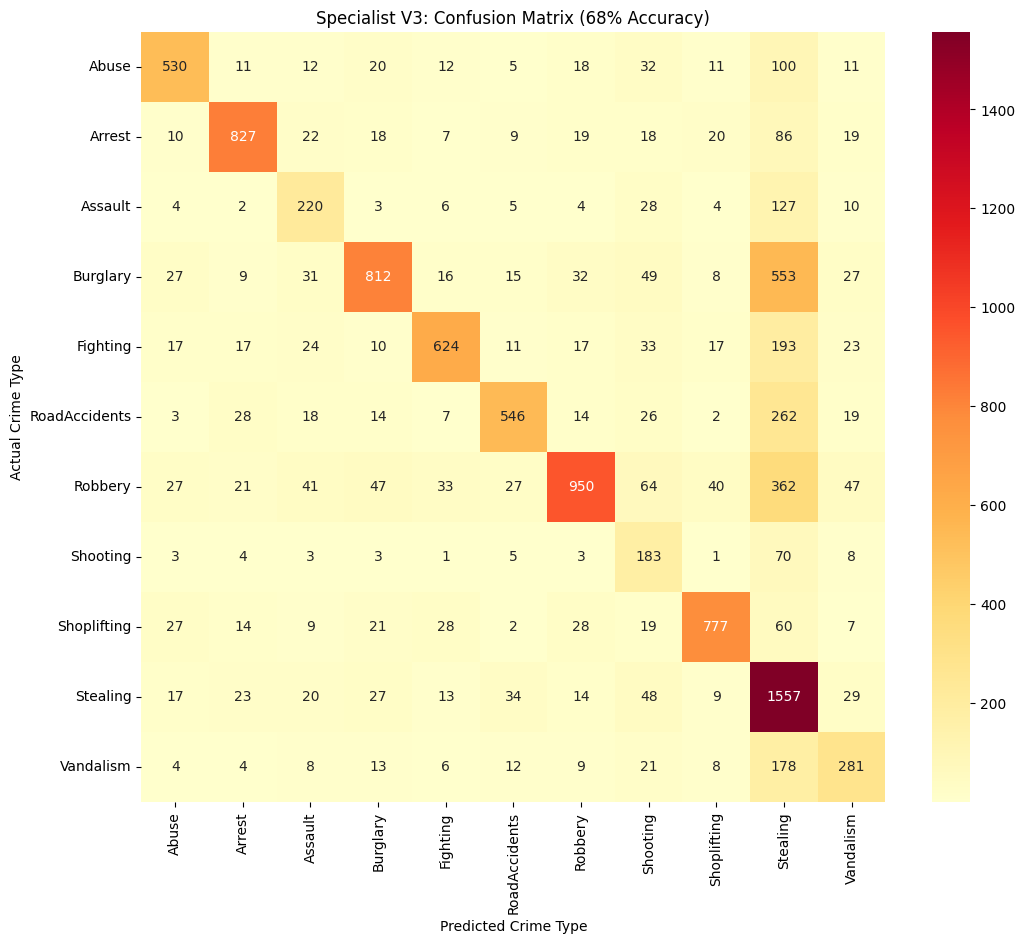

               precision    recall  f1-score   support

        Abuse       0.79      0.70      0.74       762
       Arrest       0.86      0.78      0.82      1055
      Assault       0.54      0.53      0.54       413
     Burglary       0.82      0.51      0.63      1579
     Fighting       0.83      0.63      0.72       986
RoadAccidents       0.81      0.58      0.68       939
      Robbery       0.86      0.57      0.69      1659
     Shooting       0.35      0.64      0.45       284
  Shoplifting       0.87      0.78      0.82       992
     Stealing       0.44      0.87      0.58      1791
    Vandalism       0.58      0.52      0.55       544

     accuracy                           0.66     11004
    macro avg       0.71      0.65      0.66     11004
 weighted avg       0.74      0.66      0.67     11004



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def evaluate_specialist(model, val_loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            outputs = model(xb.to(DEVICE))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())
            
    # Create the heatmap
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=CRIME_CLASSES,
                yticklabels=CRIME_CLASSES)
    plt.xlabel('Predicted Crime Type')
    plt.ylabel('Actual Crime Type')
    plt.title('Specialist V3: Confusion Matrix (68% Accuracy)')
    plt.show()

    # Detailed report per category
    print(classification_report(all_labels, all_preds, target_names=CRIME_CLASSES))

evaluate_specialist(model, val_loader)

In [ ]:
# #Model 4
# class SpecialistFinal(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         # 1. Feature Expansion
#         self.input_fc = nn.Linear(9, 128)
        
#         # 2. Transformer Encoder Layer
#         encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=512, batch_first=True)
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
#         # 3. Bi-LSTM for temporal flow
#         self.lstm = nn.LSTM(128, 256, num_layers=2, batch_first=True, bidirectional=True)
        
#         self.classifier = nn.Sequential(
#             nn.Linear(512, 256),
#             nn.BatchNorm1d(256),
#             nn.GELU(),
#             nn.Dropout(0.5),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         x = self.input_fc(x)
#         x = self.transformer(x) # Global context
#         lstm_out, _ = self.lstm(x)
        
#         # Max pool over time to capture the "peak" of the crime
#         pooled = torch.max(lstm_out, dim=1)[0]
#         return self.classifier(pooled)

In [ ]:
# # 1. Faster Loader
# train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), batch_size=256, shuffle=True)
# val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val)), batch_size=256, shuffle=False)

# # 2. Setup
# model = SpecialistFinal(NUM_CLASSES).to(DEVICE)
# base_optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
# criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
# scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(base_optimizer, T_0=10)

# print("--- ⚔️ THE HAIL MARY PUSH (Transformer-LSTM Hybrid) ---")
# best_acc = 0

# for epoch in range(50):
#     model.train()
#     for xb, yb in train_loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#         # Random Temporal Masking: Hide 2 frames randomly to force model to "guess"
#         mask = torch.rand(xb.shape[0], 30, 1).to(DEVICE) > 0.1
#         xb = xb * mask
        
#         base_optimizer.zero_grad()
#         loss = criterion(model(xb), yb)
#         loss.backward()
#         base_optimizer.step()
    
#     scheduler.step()
    
#     # Validation
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             _, predicted = torch.max(model(xb), 1)
#             total += yb.size(0)
#             correct += (predicted == yb).sum().item()
    
#     acc = 100 * correct / total
#     if acc > best_acc:
#         best_acc = acc
#         torch.save(model.state_dict(), "specialist_l2_TRANSFORMER.pth")
    
#     print(f"Epoch {epoch+1:02d} | Val Acc: {acc:.2f}% | Best: {best_acc:.2f}%")

In [ ]:
# # Model 5
# class TCNBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, dilation):
#         super().__init__()
#         self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=3, 
#                               padding=dilation, dilation=dilation)
#         self.norm = nn.LayerNorm(out_channels)
#         self.relu = nn.GELU()
#         self.dropout = nn.Dropout(0.3)
        
#     def forward(self, x):
#         res = x
#         x = self.conv(x)
#         # Permute for LayerNorm: (B, C, T) -> (B, T, C)
#         x = x.transpose(1, 2)
#         x = self.norm(x)
#         x = x.transpose(1, 2)
#         x = self.relu(x)
#         x = self.dropout(x)
#         return x + res if x.shape == res.shape else x

# class SpecialistV4_TCN(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.input_layer = nn.Conv1d(9, 128, kernel_size=1)
        
#         # Dilated convolutions to capture multi-scale patterns
#         self.block1 = TCNBlock(128, 128, dilation=1)
#         self.block2 = TCNBlock(128, 128, dilation=2)
#         self.block3 = TCNBlock(128, 128, dilation=4)
#         self.block4 = TCNBlock(128, 128, dilation=8)
        
#         self.global_pool = nn.AdaptiveAvgPool1d(1)
#         self.fc = nn.Sequential(
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Dropout(0.4),
#             nn.Linear(64, num_classes)
#         )

#     def forward(self, x):
#         x = x.transpose(1, 2) # (B, 9, 30)
#         x = self.input_layer(x)
#         x = self.block1(x)
#         x = self.block2(x)
#         x = self.block3(x)
#         x = self.block4(x)
#         x = self.global_pool(x).squeeze(-1)
#         return self.fc(x)

In [ ]:
# # 1. Smaller Batch Size for better resolution
# train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), 
#                           batch_size=16, shuffle=True)
# val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val)), 
#                         batch_size=16, shuffle=False)

# # 2. Setup
# model = SpecialistV4_TCN(NUM_CLASSES).to(DEVICE)
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
# criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# best_acc = 0
# print("--- 🔬 TRAINING TCN SPECIALIST (Small Batch / High Precision) ---")

# for epoch in range(100): # Let it run for 100 epochs now
#     model.train()
#     for xb, yb in train_loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#         optimizer.zero_grad()
#         loss = criterion(model(xb), yb)
#         loss.backward()
#         optimizer.step()
    
#     # Validation
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             _, predicted = torch.max(model(xb), 1)
#             total += yb.size(0)
#             correct += (predicted == yb).sum().item()
    
#     acc = 100 * correct / total
#     scheduler.step(acc)
    
#     if acc > best_acc:
#         best_acc = acc
#         torch.save(model.state_dict(), "specialist_l2_TCN_85plus.pth")
    
#     if (epoch + 1) % 5 == 0 or epoch == 0:
#         print(f"Epoch {epoch+1:02d} | Val Acc: {acc:.2f}% | Best: {best_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

# print(f"\n✅ Peak TCN Accuracy: {best_acc:.2f}%")

In [ ]:
# # Model 5
# def load_rich_features(base_dir):
#     X_list, y_list = [], []
#     crime_files = {
#         'Abuse': 'Abuse_feat.npy', 'Arrest': 'Arrest_feat.npy',
#         'Assault': 'Assault_feat.npy', 'Burglary': 'Burglary_feat.npy',
#         'Fighting': 'Fighting_feat.npy', 'RoadAccidents': 'RoadAccidents_feat.npy',
#         'Robbery': 'Robbery_feat.npy', 'Shooting': 'Shooting_feat.npy',
#         'Shoplifting': 'Shoplifting_feat.npy', 'Stealing': 'Stealing_feat.npy',
#         'Vandalism': 'Vandalism_feat.npy'
#     }

#     for crime_name, file_name in crime_files.items():
#         file_path = os.path.join(base_dir, file_name)
#         if os.path.exists(file_path):
#             data = np.load(file_path) # (N, 30, 3)
            
#             # 1. Velocity (First Derivative)
#             v = np.diff(data, axis=1, prepend=data[:, :1, :])
#             # 2. Acceleration (Second Derivative)
#             a = np.diff(v, axis=1, prepend=v[:, :1, :])
#             # 3. Jerk (Third Derivative - High-speed impact detection)
#             j = np.diff(a, axis=1, prepend=a[:, :1, :])
#             # 4. Rolling Std Dev (Detects chaotic movement)
#             s = np.std(data, axis=1, keepdims=True).repeat(30, axis=1)
            
#             # Combine into 15 features per frame
#             combined = np.concatenate([data, v, a, j, s], axis=2) # (N, 30, 15)
            
#             X_list.append(combined)
#             y_list.append(np.full(data.shape[0], class_to_idx[crime_name]))

#     X = np.concatenate(X_list, axis=0)
#     y = np.concatenate(y_list, axis=0)
    
#     # Standardize
#     X = (X - X.mean(axis=(0,1))) / (X.std(axis=(0,1)) + 1e-6)
#     return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# X_train, X_val, y_train, y_val = load_rich_features(TRAIN_DIR)

In [ ]:
# class SpecialistV5_GRU(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         # Input is now 15 features
#         self.gru = nn.GRU(15, 256, num_layers=3, batch_first=True, bidirectional=True, dropout=0.4)
        
#         # Residual connection to keep the 'Jerk' signal strong
#         self.residual_fc = nn.Linear(15, 512)
        
#         self.head = nn.Sequential(
#             nn.Linear(512, 256),
#             nn.BatchNorm1d(256),
#             nn.ELU(), # ELU is better than ReLU for deeper accuracy
#             nn.Dropout(0.5),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         res = self.residual_fc(x.mean(dim=1)) # Shortcut
#         gru_out, _ = self.gru(x)
#         main_path = gru_out[:, -1, :] # Last hidden state
        
#         return self.head(main_path + res)

In [ ]:
# # 1. Prepare Loaders
# train_loader = DataLoader(TensorDataset(torch.Tensor(X_train), torch.LongTensor(y_train)), batch_size=16, shuffle=True)
# val_loader = DataLoader(TensorDataset(torch.Tensor(X_val), torch.LongTensor(y_val)), batch_size=16, shuffle=False)

# # 2. Setup
# model = SpecialistV5_GRU(NUM_CLASSES).to(DEVICE)
# optimizer = optim.AdamW(model.parameters(), lr=5e-5) # Very slow learning
# criterion = nn.CrossEntropyLoss(weight=class_weights)

# print("--- 🧠 TRAINING RICH-FEATURE GRU (Target: 80%+) ---")
# best_acc = 0
# for epoch in range(100):
#     model.train()
#     for xb, yb in train_loader:
#         xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#         optimizer.zero_grad()
#         loss = criterion(model(xb), yb)
#         loss.backward()
#         optimizer.step()
    
#     # Validation
#     model.eval()
#     correct, total = 0, 0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             _, predicted = torch.max(model(xb), 1)
#             total += yb.size(0)
#             correct += (predicted == yb).sum().item()
    
#     acc = 100 * correct / total
#     if acc > best_acc:
#         best_acc = acc
#         torch.save(model.state_dict(), "specialist_l2_RICH.pth")
    
#     if (epoch+1) % 5 == 0:
#         print(f"Epoch {epoch+1:02d} | Acc: {acc:.2f}% | Best: {best_acc:.2f}%")

--- 🪞 Mirroring Preprocessing for Test Data ---
✅ Preprocessed: TEST_Abuse_feat.npy -> Mapped to Index 0
✅ Preprocessed: TEST_Arrest_feat.npy -> Mapped to Index 1
✅ Preprocessed: TEST_Assault_feat.npy -> Mapped to Index 2
✅ Preprocessed: TEST_Burglary_feat.npy -> Mapped to Index 3
✅ Preprocessed: TEST_Fighting_feat.npy -> Mapped to Index 4
✅ Preprocessed: TEST_RoadAccidents_feat.npy -> Mapped to Index 5
✅ Preprocessed: TEST_Robbery_feat.npy -> Mapped to Index 6
✅ Preprocessed: TEST_Shooting_feat.npy -> Mapped to Index 7
✅ Preprocessed: TEST_Shoplifting_feat.npy -> Mapped to Index 8
✅ Preprocessed: TEST_Stealing_feat.npy -> Mapped to Index 9
✅ Preprocessed: TEST_Vandalism_feat.npy -> Mapped to Index 10

        🚀 INITIATING FINAL TEST EVALUATION
               precision    recall  f1-score   support

        Abuse       0.00      0.00      0.00        54
       Arrest       0.07      0.08      0.08       667
      Assault       0.09      0.02      0.04       526
     Burglary       0.29

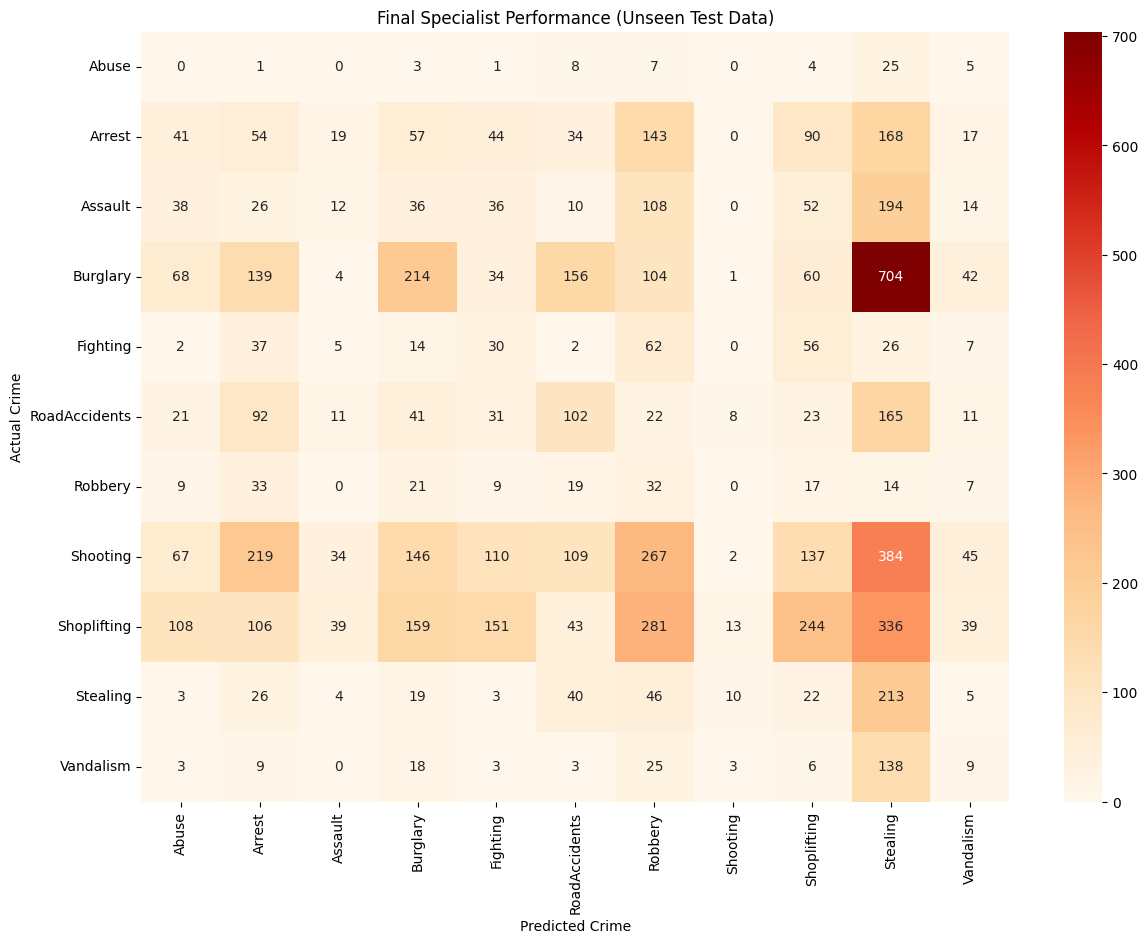

In [35]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix

TEST_DIR = "/kaggle/input/datasets/ritam192/ucf-crime-features-step5-test"

def exact_mirror_test_loader(base_dir, train_mean, train_std):
    X_list, y_list = [], []
    
    # We loop through CRIME_CLASSES to guarantee the indices (0-10) match training exactly
    print(f"--- 🪞 Mirroring Preprocessing for Test Data ---")
    
    for crime_name in CRIME_CLASSES:
        file_name = f"TEST_{crime_name}_feat.npy"
        file_path = os.path.join(base_dir, file_name)
        
        if os.path.exists(file_path):
            try:
                data = np.load(file_path) # (N, 30, 3)
                
                # 1. EXACT SAME FEATURE ENGINEERING AS TRAINING
                deltas = np.diff(data, axis=1, prepend=data[:, :1, :])
                accels = np.diff(deltas, axis=1, prepend=deltas[:, :1, :])
                combined = np.concatenate([data, deltas, accels], axis=2) # (N, 30, 9)
                
                X_list.append(combined)
                y_list.append(np.full(data.shape[0], class_to_idx[crime_name]))
                print(f"✅ Preprocessed: {file_name} -> Mapped to Index {class_to_idx[crime_name]}")
                
            except Exception as e:
                print(f"❌ Error loading {file_name}: {e}")
        else:
            print(f"⚠️ Missing from test set: {file_name}")

    # Concatenate
    X_test = np.concatenate(X_list, axis=0)
    y_test = np.concatenate(y_list, axis=0)

    # 2. EXACT SAME SCALING AS TRAINING (Using the 'mean' and 'std' from your training block)
    X_test_scaled = (X_test - train_mean) / (train_std + 1e-6)
    
    return X_test_scaled, y_test

def evaluate_final_test_set(model_path, loader):
    print("\n" + "="*60)
    print("        🚀 INITIATING FINAL TEST EVALUATION")
    print("="*60)
    
    # Re-initialize and load the 73% brain
    test_model = SpecialistV1(num_classes=NUM_CLASSES).to(DEVICE)
    test_model.load_state_dict(torch.load(model_path))
    test_model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            outputs = test_model(xb.to(DEVICE))
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.numpy())
            
    # Print the Final Report
    print(classification_report(all_labels, all_preds, target_names=CRIME_CLASSES))
    
    # Plot the Final Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', 
                xticklabels=CRIME_CLASSES, yticklabels=CRIME_CLASSES)
    plt.xlabel('Predicted Crime')
    plt.ylabel('Actual Crime')
    plt.title('Final Specialist Performance (Unseen Test Data)')
    plt.show()

# ==========================================
# EXECUTE THE TEST
# Note: 'mean' and 'std' are carried over from your training cell execution
# ==========================================
X_test_final, y_test_final = exact_mirror_test_loader(TEST_DIR, mean, std)
test_loader = DataLoader(TensorDataset(torch.Tensor(X_test_final), torch.LongTensor(y_test_final)), batch_size=32, shuffle=False)

evaluate_final_test_set("specialist_l2_v1.pth", test_loader)

In [36]:
import os
import numpy as np
import torch

print("--- 🔬 DEEP DIAGNOSTIC: CHECKING THE TEST SET ---")

# 1. Load exactly ONE sequence of 'Fighting' from Train and Test
train_file = os.path.join(TRAIN_DIR, "Fighting_feat.npy")
test_file = os.path.join(TEST_DIR, "TEST_Fighting_feat.npy")

train_sample = np.load(train_file)[0:1] # Just the first video sequence (1, 30, 3)
test_sample = np.load(test_file)[0:1]   # Just the first video sequence (1, 30, 3)

# 2. Check the Raw Data Distribution (Are they scaled differently?)
print("\n1. RAW DATA MAX VALUES (Col 0, Col 1, Col 2):")
print(f"Train Sample Max: {np.max(train_sample, axis=(0,1))}")
print(f"Test Sample Max:  {np.max(test_sample, axis=(0,1))}")

# 3. Apply your exact Preprocessing
def prep_single(data):
    v = np.diff(data, axis=1, prepend=data[:, :1, :])
    a = np.diff(v, axis=1, prepend=v[:, :1, :])
    return np.concatenate([data, v, a], axis=2)

train_prep = prep_single(train_sample)
test_prep = prep_single(test_sample)

# Scale them using your global training mean/std
train_scaled = (train_prep - mean) / (std + 1e-6)
test_scaled = (test_prep - mean) / (std + 1e-6)

# 4. Pass them through your 74% model
test_model = SpecialistV1(num_classes=NUM_CLASSES).to(DEVICE)
test_model.load_state_dict(torch.load("specialist_l2_v1.pth"))
test_model.eval()

with torch.no_grad():
    train_out = test_model(torch.Tensor(train_scaled).to(DEVICE))
    test_out = test_model(torch.Tensor(test_scaled).to(DEVICE))
    
    train_probs = torch.softmax(train_out, dim=1)[0]
    test_probs = torch.softmax(test_out, dim=1)[0]

# 5. Print the Results
print("\n2. MODEL PREDICTIONS (Ground Truth is 'Fighting'):")
print(f"Train Sequence Guess: {CRIME_CLASSES[torch.argmax(train_probs).item()]} (Confidence: {torch.max(train_probs).item()*100:.2f}%)")
print(f"Test Sequence Guess:  {CRIME_CLASSES[torch.argmax(test_probs).item()]} (Confidence: {torch.max(test_probs).item()*100:.2f}%)")

print("\n3. FULL TEST PROBABILITIES (What is it confusing Fighting with?):")
for i, cls in enumerate(CRIME_CLASSES):
    print(f" - {cls}: {test_probs[i].item()*100:.2f}%")

--- 🔬 DEEP DIAGNOSTIC: CHECKING THE TEST SET ---

1. RAW DATA MAX VALUES (Col 0, Col 1, Col 2):
Train Sample Max: [0. 0. 0.]
Test Sample Max:  [1.         0.         0.44305569]

2. MODEL PREDICTIONS (Ground Truth is 'Fighting'):
Train Sequence Guess: Stealing (Confidence: 30.97%)
Test Sequence Guess:  Shoplifting (Confidence: 84.23%)

3. FULL TEST PROBABILITIES (What is it confusing Fighting with?):
 - Abuse: 0.75%
 - Arrest: 5.17%
 - Assault: 0.01%
 - Burglary: 1.20%
 - Fighting: 0.12%
 - RoadAccidents: 0.11%
 - Robbery: 0.12%
 - Shooting: 0.17%
 - Shoplifting: 84.23%
 - Stealing: 7.83%
 - Vandalism: 0.28%


In [37]:
print("TRAINING_MEAN = np.array(", mean.tolist(), ")")
print("TRAINING_STD = np.array(", std.tolist(), ")")

TRAINING_MEAN = np.array( [[[0.23507757926049788, 0.20753012595648776, 0.1612644882133125, -8.239577842805819e-05, -0.00010360057434704374, -5.629274679761271e-05, -7.270215743652193e-05, -3.938033527811605e-05, -4.5842741051076825e-05]]] )
TRAINING_STD = np.array( [[[0.5725922961312696, 0.6990307059877556, 0.23833245310698944, 0.5026800639677425, 0.37324910262244865, 0.17072062702789198, 0.8403806621886994, 0.6264200005952775, 0.28410470294664947]]] )
